# Lab 2: Image Transformation

## Theory

### Scaling
Scaling is just resizing of the image. OpenCV comes with a function cv2.resize() for
this purpose. The size of the image can be specified manually, or you can specify the scaling
factor.

### Thresholding
Here, the matter is straight forward. If pixel value is greater than a threshold
value, it is assigned one value (may be white), else it is assigned another value (may be black).
The function used is `cv2.threshold`. First argument is the source image, which should be a
grayscale image. Second argument is the threshold value which is used to classify the pixel
values. Third argument is the maxVal which represents the value to be given if pixel value is
more than (sometimes less than) the threshold value. OpenCV provides different styles of
thresholding and it is decided by the fourth parameter of the function.

## Experiments

### 1. Write a program to detect edge of a image.

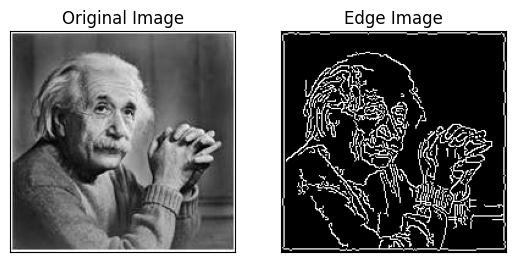

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread("./img/einstein.jpg",0)

edges = cv2.Canny(img,100,200)

plt.subplot(121),plt.imshow(img,cmap = "gray")
plt.title("Original Image"), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = "gray")
plt.title("Edge Image"), plt.xticks([]), plt.yticks([])
plt.show()

## 2. Write a program to scale an image.

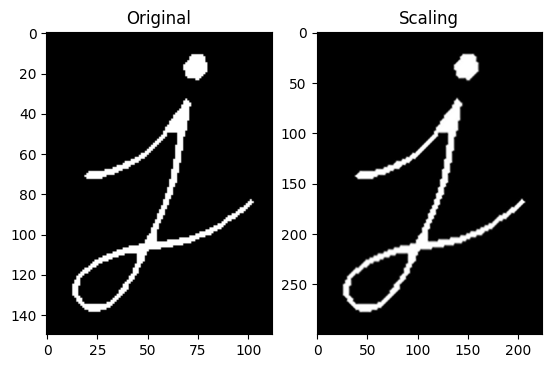

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread("./img/j.png")

#res = cv2.resize(img,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)
height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)

plt.subplot(121),plt.imshow(img),plt.title("Original")
#plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(res),plt.title("Scaling")
#plt.xticks([]), plt.yticks([])
plt.show()

## 3. Write a program showing a thresholding process on an image

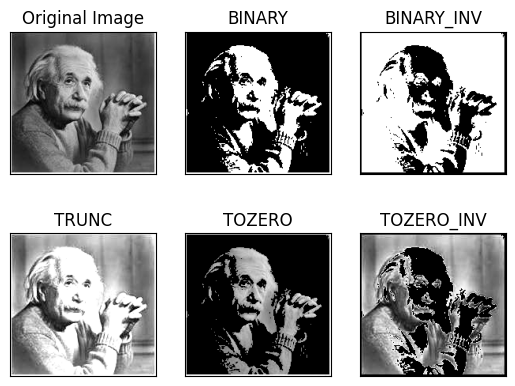

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread("./img/einstein.jpg",0)

ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)

titles = ["Original Image","BINARY","BINARY_INV","TRUNC","TOZERO","TOZERO_INV"]
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],"gray")
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
    
plt.show()

### Image Enhancement in Spatial Domain

In [1]:
# ──────────────────────────────────────────────────────────────
# CELL 1: Install & Imports (Run this first)
# ──────────────────────────────────────────────────────────────

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure
# from google.colab.patches import cv2_imshow
def show(images, titles, cmap_list=None, figsize=(16, 4)):
    """Helper: display multiple images side by side."""
    n = len(images)
    if cmap_list is None:
        cmap_list = ['gray'] * n
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title, cmap in zip(axes, images, titles, cmap_list):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
# Load a sample grayscale image (use your own: cv2.imread('path'))
img_gray = cv2.cvtColor(
    cv2.resize(
        np.array(data.camera(), dtype=np.uint8),
        (512, 512)
    ), cv2.COLOR_GRAY2BGR
)
img_gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY)
print(" Setup complete. Image shape:", img_gray.shape)

 Setup complete. Image shape: (512, 512)


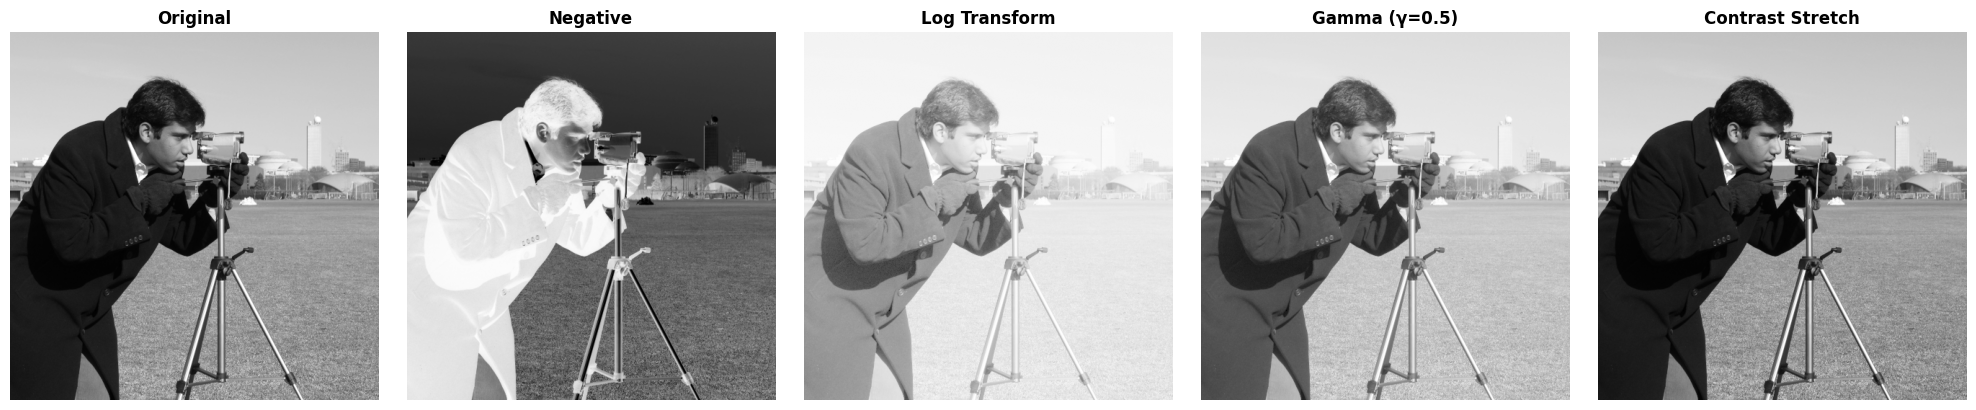

 Intensity Transformations complete.


In [2]:
# ──────────────────────────────────────────────────────────────
# CELL 2: PROGRAM 1 — Intensity Transformations
#         (Negative, Log, Power/Gamma, Contrast Stretching)
# ──────────────────────────────────────────────────────────────
def intensity_transformations(img):
    img = img.astype(np.float64)
    L = 256  # gray levels
    # 1. Image Negative
    negative = L - 1 - img
    # 2. Log Transformation: s = c * log(1 + r)
    c = (L - 1) / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)
    # 3. Power-Law (Gamma) Transformation: s = c * r^gamma
    gamma = 0.5   # <1 brightens, >1 darkens
    c = 1.0
    gamma_img = c * np.power(img / 255.0, gamma) * 255
    # 4. Contrast Stretching: linear stretch to [0, 255]
    r_min, r_max = img.min(), img.max()
    contrast = (img - r_min) / (r_max - r_min) * 255
    images = [
        img.astype(np.uint8),
        negative.astype(np.uint8),
        log_img.astype(np.uint8),
        gamma_img.astype(np.uint8),
        contrast.astype(np.uint8)
    ]
    titles = ['Original', 'Negative', 'Log Transform',
              f'Gamma (γ={gamma})', 'Contrast Stretch']
    show(images, titles, figsize=(20, 4))
    print(" Intensity Transformations complete.")
intensity_transformations(img_gray)

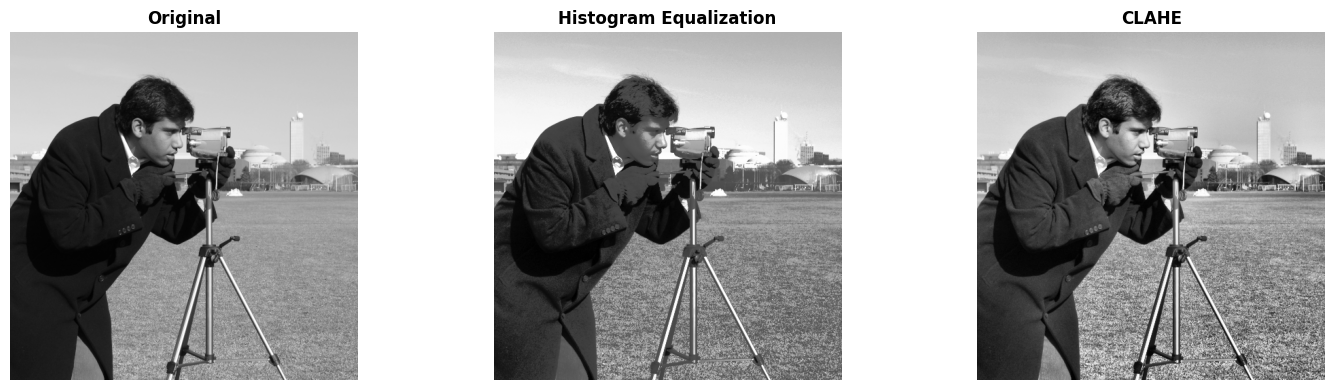

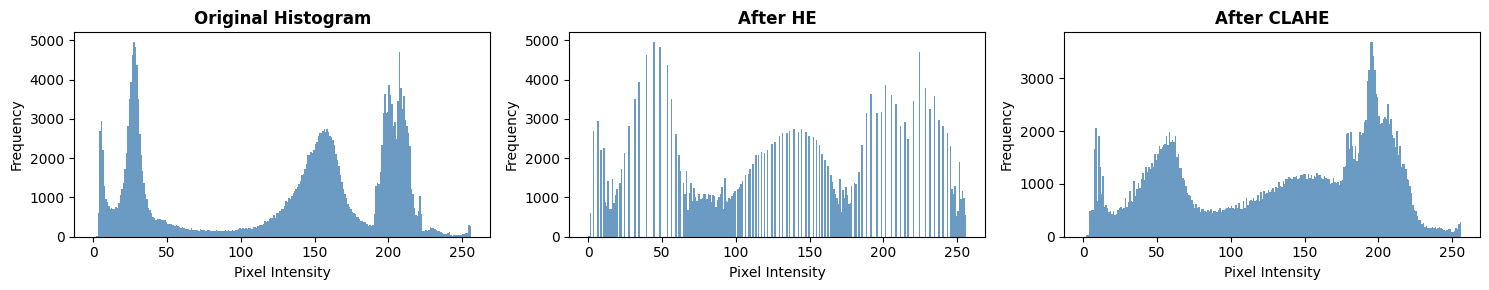

 Histogram Processing complete.


In [3]:
# ──────────────────────────────────────────────────────────────
# CELL 3: PROGRAM 2 — Histogram Processing
#         (Histogram Equalization & CLAHE)
# ──────────────────────────────────────────────────────────────
def histogram_processing(img):
    # Standard Histogram Equalization
    hist_eq = cv2.equalizeHist(img)
    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(img)
    # Plot images
    show(
        [img, hist_eq, clahe_img],
        ['Original', 'Histogram Equalization', 'CLAHE'],
        figsize=(15, 4)
    )
    # Plot histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    for ax, image, title in zip(axes,
                                 [img, hist_eq, clahe_img],
                                 ['Original Histogram', 'After HE', 'After CLAHE']):
        ax.hist(image.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Pixel Intensity')
        ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    print(" Histogram Processing complete.")
histogram_processing(img_gray)

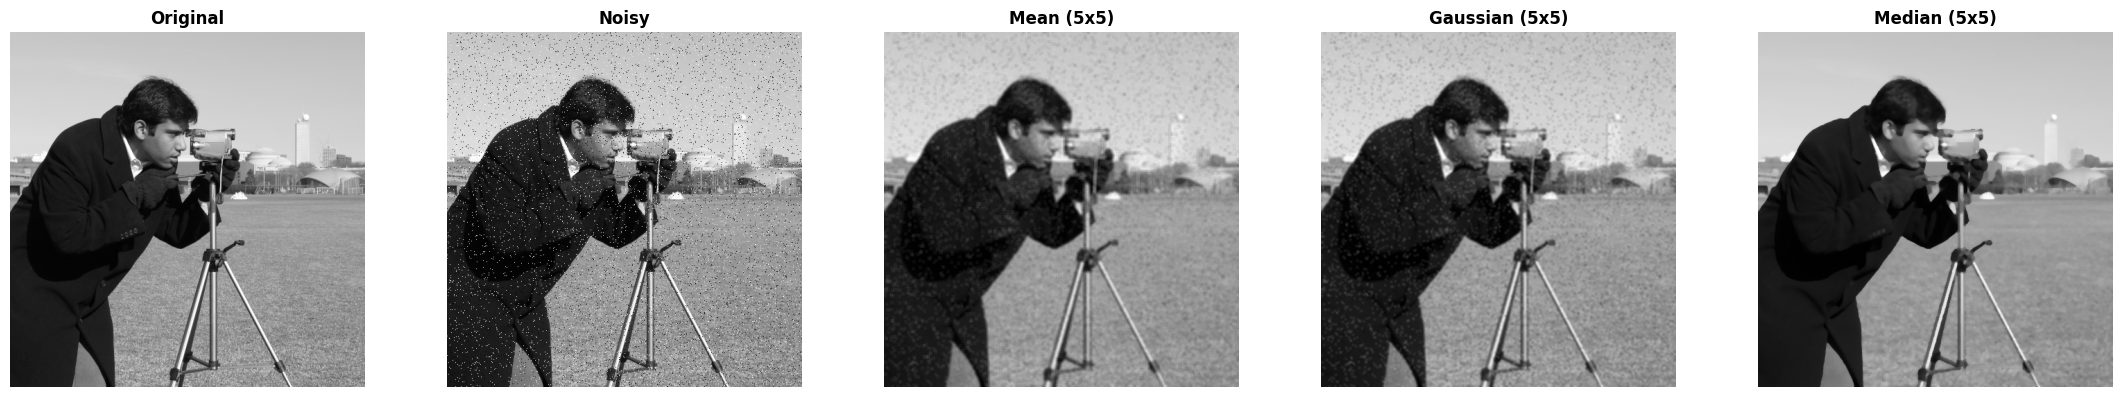

 Smoothing Filters complete.


In [4]:
# ──────────────────────────────────────────────────────────────
# CELL 4: PROGRAM 3 — Spatial Filtering (Smoothing)
#         (Mean, Gaussian, Median filters)
# ──────────────────────────────────────────────────────────────
def smoothing_filters(img):
    # Add salt-and-pepper noise for demonstration
    noisy = img.copy()
    num_salt = int(0.02 * img.size)
    coords = [np.random.randint(0, d, num_salt) for d in img.shape]
    noisy[tuple(coords)] = 255
    coords = [np.random.randint(0, d, num_salt) for d in img.shape]
    noisy[tuple(coords)] = 0
    ksize = 5  # kernel size
    # 1. Mean (Averaging) Filter
    mean_f = cv2.blur(noisy, (ksize, ksize))
    # 2. Gaussian Filter
    gauss_f = cv2.GaussianBlur(noisy, (ksize, ksize), sigmaX=1.5)
    # 3. Median Filter (best for salt-and-pepper)
    median_f = cv2.medianBlur(noisy, ksize)
    show(
        [img, noisy, mean_f, gauss_f, median_f],
        ['Original', 'Noisy', f'Mean ({ksize}x{ksize})',
         f'Gaussian ({ksize}x{ksize})', f'Median ({ksize}x{ksize})'],
        figsize=(22, 4)
    )
    print(" Smoothing Filters complete.")
smoothing_filters(img_gray)

In [7]:
# ──────────────────────────────────────────────────────────────
# CELL 5: PROGRAM 4 — Spatial Filtering (Sharpening)
#         (Laplacian, Unsharp Masking, Sobel Gradient)
# ──────────────────────────────────────────────────────────────
def sharpening_filters(img):
    img_f = img.astype(np.float64)
    # 1. Laplacian Sharpening: s = f - ∇²f  (enhances edges)
    laplacian_kernel = np.array([[0, -1, 0],
                                  [-1, 4, -1],
                                  [0, -1, 0]], dtype=np.float64)
    laplacian = cv2.filter2D(img_f, -1, laplacian_kernel)
    laplacian_sharp = np.clip(img_f - laplacian, 0, 255).astype(np.uint8)
    # 2. Unsharp Masking: sharpened = original + k*(original - blurred)
    k = 1.5
    blurred = cv2.GaussianBlur(img, (9, 9), sigmaX=2.0).astype(np.float64)
    unsharp = np.clip(img_f + k * (img_f - blurred), 0, 255).astype(np.uint8)
    # 3. Sobel Gradient (edge detection / high-frequency enhancement)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.clip(np.sqrt(sobelx**2 + sobely**2), 0, 255).astype(np.uint8)
    show(
        [img, laplacian_sharp, unsharp, sobel_mag],
    )
    ['Original', 'Laplacian Sharpened', 'Unsharp Masking', 'Sobel Gradient'],
    figsize=(18, 4)
    print(" Sharpening Filters complete.")
    sharpening_filters(img_gray)

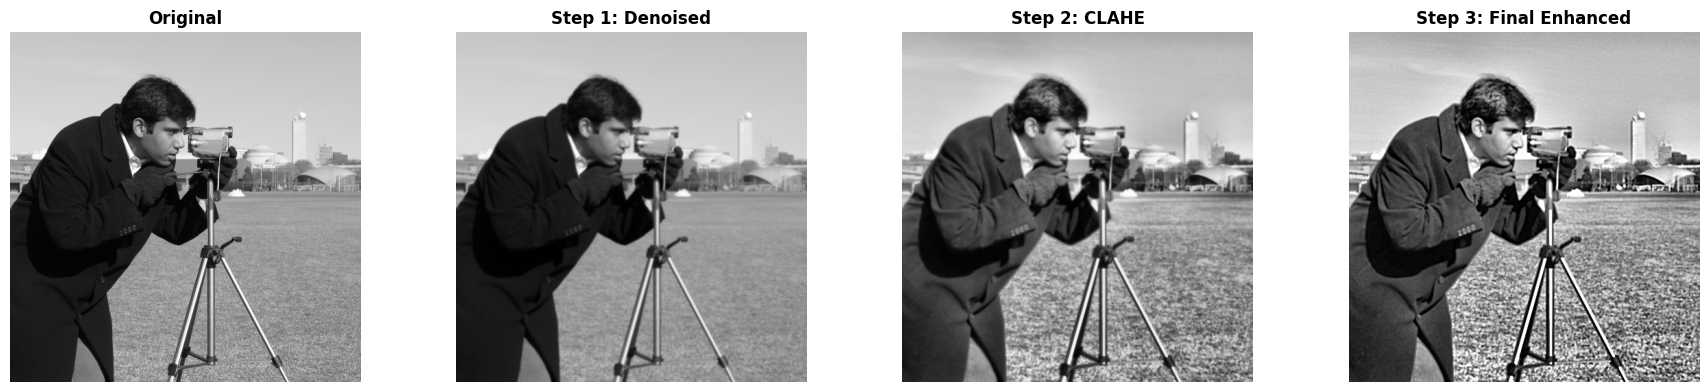

 Full Pipeline complete. PSNR (original vs enhanced): 18.59 dB


In [8]:
# ──────────────────────────────────────────────────────────────
# CELL 6: PROGRAM 5 — Combined Enhancement Pipeline
#         (Noise removal → CLAHE → Sharpening)
# ──────────────────────────────────────────────────────────────
def full_enhancement_pipeline(img):
    """
    A realistic image enhancement pipeline:
      Step 1: Denoise with Gaussian filter
      Step 2: CLAHE for contrast enhancement
      Step 3: Unsharp masking for sharpness
    """
    # Step 1: Denoise
    denoised = cv2.GaussianBlur(img, (5, 5), sigmaX=1.0)
    # Step 2: CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    # Step 3: Unsharp Masking
    blurred = cv2.GaussianBlur(enhanced, (9, 9), sigmaX=2.0).astype(np.float64)
    k = 1.2
    sharpened = np.clip(enhanced.astype(np.float64) + k * (enhanced.astype(np.float64) - blurred), 0, 255).astype(np.uint8)
    show(
        [img, denoised, enhanced, sharpened],
        ['Original', 'Step 1: Denoised', 'Step 2: CLAHE', 'Step 3: Final Enhanced'],
        figsize=(18, 4)
    )
    # PSNR metric (quality measure)
    psnr = cv2.PSNR(img, sharpened)
    print(f" Full Pipeline complete. PSNR (original vs enhanced): {psnr:.2f} dB")
full_enhancement_pipeline(img_gray)